Nome: Vinicius de Souza Trentin

RA: 298990

Curso: IA901



# Ex03 - Transformações de Intensidade (operações radiométricas)

Esta atividade tem 2 objetivos principais: 
  - Entender o que são transformações radiométricas e como podem ser implementadas
  - Explorar duas aplicações para as transformações radiométricas: normalização e segmentação. 

In [2]:
# Importando as bibliotecas que serão utilizadas
import os

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import requests
from PIL import Image

In [4]:
def download_image(url:str) -> str:
    filename = os.path.basename(url)

    if os.path.exists(filename):
        return filename

    response = requests.get(url)

    with open(filename, mode="wb") as file:
        file.write(response.content)

    return filename

## Parte 1 - Manipulando imagens

O código abaixo baixa e lê a imagem *flower.pgm* utilizando a biblioteca PIL/pillow, apresenta a imagem na tela e a transforma num array numpy.

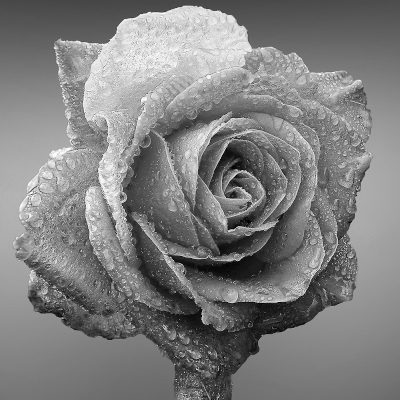

[[ 72  72  72 ...  78  77  77]
 [ 73  72  73 ...  78  78  78]
 [ 73  73  74 ...  78  78  79]
 ...
 [118 117 116 ... 107 107 106]
 [116 115 115 ... 106 106 106]
 [116 116 115 ... 106 106 106]]


In [5]:
url = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/imgs/flower.pgm"
img_file = download_image(url)
img = Image.open(img_file)
display(img)

# Convertendo para um array do numpy
f=np.asarray(img)
print(f)

É bastante útil poder transformar Images em PIL em arrays numpy, e vice-versa. Isso permitirá que realizemos operações matriciais nas imagens e posteriormente possamos visualizar (e salvar em arquivos) as imagens processadas. 

### Exercício 1.1 

**a)** Classifique a imagem como monocromática (binária, grayscale) ou multibanda (tentando identificar o padrão multibanda adotado). Descubra: qual a profundidade da imagem? Qual o maior e o menor valor de intensidade de pixel da imagem (da imagem, não o teórico da profundidade)? Utilize para isso a biblioteca NumPy.

In [6]:
def analyze_image_properties(image_array):
    # Extraindo o tipo de dados que representa a profundidade da imagem
    img_depth = image_array.dtype
    
    # Calculo dos valores minimo e maximo de intensidade de pixel
    min_intensity = np.min(image_array)
    max_intensity = np.max(image_array)
    
    print(f"Profundidade da imagem (Tipo de dados): {img_depth}")
    print(f"Valor mínimo de intensidade de pixel: {min_intensity}")
    print(f"Valor máximo de intensidade do pixel: {max_intensity}")

analyze_image_properties(f)

# A imagem é monocromática(possui apenas um canal), é uma imagem grayscale(escala de cinza). 
# De acordo com os resultados, a profundidade da imagem é de 8 bits por pixel(uint8)
# O Maior valor da intensidade de pixel da imagem é 0
# O menor valor da intensidade de pixel da imagem é 253

Profundidade da imagem (Tipo de dados): uint8
Valor mínimo de intensidade de pixel: 0
Valor máximo de intensidade do pixel: 253


Tendo em vista que a imagem possui apenas um canal, ela é monocromática. Como os valores das intensidades dos pixels vai de 0 a 253, ela é uma imagem grayscale.

A profundidade da imagem é de 8 bits por pixel (uint8).

Maior valor de intensidade de pixel: 253
Menor valor de intensidade de pixel: 0


**b)** Leia a imagem *flower.pgm* utilizando a biblioteca matplotlib.image e mostre-a na tela. Exercite também o uso da barra de cores (colorbar).

Referência: [Tutorial Image Matplotlib](https://matplotlib.org/3.5.0/tutorials/introductory/images.html) 

<details>
<summary>Dicas</summary>

- [matplotlib.pyplot.colobar](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.colorbar.html)

</details>

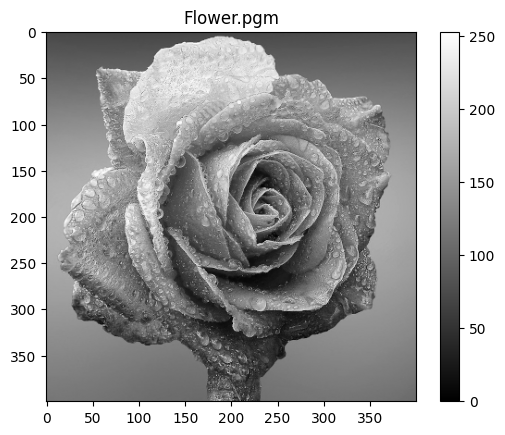

In [7]:
def display_image_with_colorbar(image_path):
    # Lendo a imagem usando matplotlib.imagendo
    img_array = mpimg.imread(image_path)
    # Exibindo a imagem, usando cmap='gray' para mostrar a escala de cinza original.
    imgplot = plt.imshow(img_array, cmap='gray')
    # Adicionando a barra de cores ao grafico.
    plt.colorbar(imgplot)
    plt.title("Flower.pgm")
    plt.show()

display_image_with_colorbar(img_file)

**c)** Usando atributos do tipo [`Image`](https://pillow.readthedocs.io/en/stable/reference/Image.html#image-attributes) da biblioteca `PIL`, tente responder as mesmas perguntas do item **a)**.

In [8]:
def analyze_pil_image_attributes(img_obj):
    # Extraindo o modo de imagem (por exemplo, 'L' para escala de cinza de 8 bits, 'RGB' para cor)
    img_mode = img_obj.mode
    
    # Extraindo as bandas da imagem para confirmar que se trata de uma imagem de banda unica (monocromatica).
    img_bands = img_obj.getbands()
    
    # Extraindo os valores minimo e maximo dos pixels usando getextrema()
    # Para imagens de banda unica, retorna uma tupla contendo (minimo, maximo)
    min_intensity, max_intensity = img_obj.getextrema()
    
    print(f"Modo de imagem: {img_mode}")
    print(f"Bandas de imagem: {img_bands}")
    print(f"Valor minimo de intensidade de pixel: {min_intensity}")
    print(f"Valor maximo de intensidade de pixel: {max_intensity}")

analyze_pil_image_attributes(img)

# De acordo com os resultados, o modo de uma imagem é uma string que define o tipo e a profundidade de um pixel na imagem.
# Em que cada pixel usa toda a gama de profundidade de bits. No caso o 'L' representa que está na escala de cinza(grayscale)
# e banda de 8 bits, onde o valor minimo de intensidade de pixels da imagem foi 0 e o maximo 253

Modo de imagem: L
Bandas de imagem: ('L',)
Valor minimo de intensidade de pixel: 0
Valor maximo de intensidade de pixel: 253


O modo de uma imagem é uma string que define o tipo e a profundidade de um pixel na imagem. Cada pixel usa toda a gama de profundidade de bits. 

Um pixel de 8 bits tem um intervalo de 0-255.

L: pixels de 8 bits, preto e branco

### Exercício 1.2

Imagine que a imagem está um pouco clara demais e decido escurecê-la um pouco. Minha primeira ideia seria subtrair um valor de cada pixel, uma vez que valores menores correspondem a cores mais escuras. 

[[235 235 235 ... 241 240 240]
 [236 235 236 ... 241 241 241]
 [236 236 237 ... 241 241 242]
 ...
 [ 25  24  23 ...  14  14  13]
 [ 23  22  22 ...  13  13  13]
 [ 23  23  22 ...  13  13  13]]


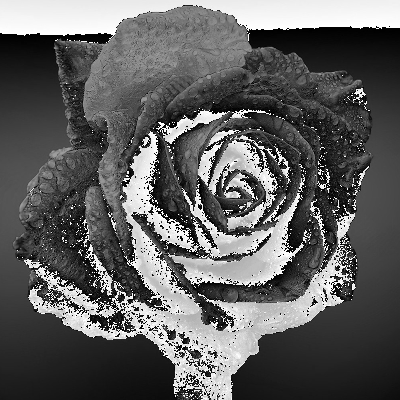

In [9]:
# Vou escurecer a imagem, subtraindo um valor dos pixels do array f.
g=f-93 
print(g)
# Agora vou transformar o array numa imagem PIL
g_img=Image.fromarray(g)
# E visualizar o resultado usando a função do PIL display
display(g_img)

**a)** Porque a imagem ficou mais clara ao invés de mais escura? Explique porque ao subtrair um determinado valor de intensidade da imagem original algumas regiões da imagem ficaram saturadas em branco.

*RESPOSTA:*

Como o tipo da imagem (dtype) é uint8, ela é capaz de representar apenas valores que vão de 0 a 255, não sendo capaz de representar valores negativos. Ao subtrair 93 de valores menores que 93, e obter valores negativos, a representação retorna os valores abaixo da saturação (255).

---
A principal mensagem é que podemos realizar operações quaisquer com os valores de pixel mas, no fim do dia, caso queiramos visualizar essas imagens, temos que pensar como esses valores serão mapeados para uma codificação que faça sentido no seu sistema computacional de apresentação.


**b)** Tente refazer esta mesma operação de "escurecimento" da imagem através de subtração, sem que esse efeito de saturação aconteça. Comente os métodos utilizados.

<details>
<summary>Dicas</summary>

- [numpy.clip](https://numpy.org/doc/stable/reference/generated/numpy.clip.html)

</details>

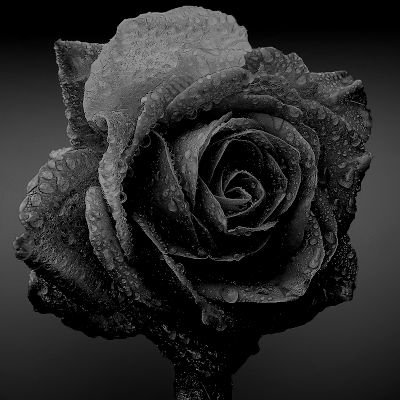

In [10]:
def darken_image_safe(image_array, subtract_value):
    # Converter para int16 para realizar a subtração com segurança, evitando o estouro negativo (underflow).
    safe_array = image_array.astype(np.int16)
    
    # Subtraindo o valor (os resultados negativos agora estão armazenados com segurança)
    darkened_array = safe_array - subtract_value
    
    # Recortar os valores para que permaneçam dentro dos limites de escala de cinza de 0 a 255.
    clipped_array = np.clip(darkened_array, 0, 255)
    
    # Convertendo de volta para uint8 para uma representação de imagem adequada.
    final_array = clipped_array.astype(np.uint8)

    return final_array

# Aplicando a função segura usando o array original 'f'
h = darken_image_safe(f, 93)

# Criando a imagem PIL a partir da matriz corrigida e exibindo-a.
h_img = Image.fromarray(h)
display(h_img)

# Dessa forma, a imagem ficara uniformemente mais escura, sem os "estouros" de branco nas areas de sombra 
# e mantendo o contraste natural nas areas iluminadas.


## Parte 2 - Transformação de Intensidade

Tranformações de intensidade ou transformações rediométricas alteram o valor do pixel aplicando-se uma função ou tabela de mapeamento. Para entender como isso é implementado na prática, estudem atentamente o tutorial sobre ["Transformações de intensidade"](https://github.com/lrittner/Computacao-Visual/blob/master/tutoriais/tutorial_ti_2.ipynb).

[[ 72  72  72 ...  78  77  77]
 [ 73  72  73 ...  78  78  78]
 [ 73  73  74 ...  78  78  79]
 ...
 [118 117 116 ... 107 107 106]
 [116 115 115 ... 106 106 106]
 [116 116 115 ... 106 106 106]]


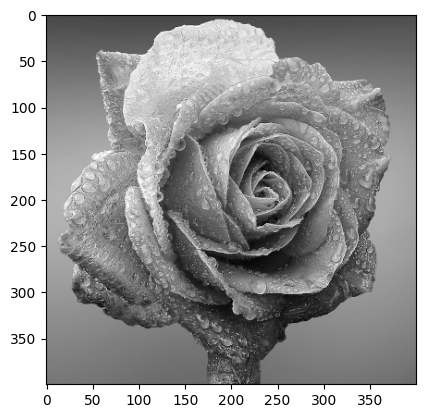

In [11]:
print(f)
plt.imshow(f,cmap='gray')

Vamos exercitar a aplicação de um mapeamento f = T[f] a partir de uma função de transformação T. No nosso caso, a função T será o negativo da imagem.

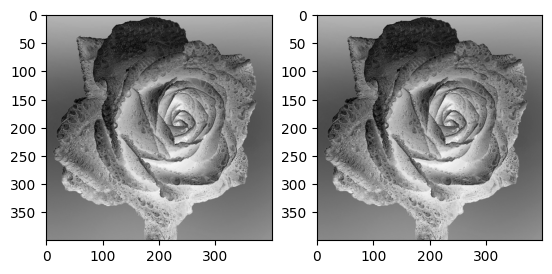

In [12]:
T = np.arange(256).astype('uint8')        # função identidade
T1 = 255 - T                              # criando a função negação a partir da identidade
#print(T1)
T2 = np.arange(255,-1,-1).astype('uint8') # criando diretamente a função negação
#print(T2)

plt.subplot(1,2,1)
f1 = T1[f]
plt.imshow(f1,cmap='gray')
plt.subplot(1,2,2)
f2 = T2[f]
plt.imshow(f2,cmap='gray')


### Exercício 2.1

Utilize transformações radiométricas para transformar a imagem e identificar o número da placa do carro apresentado na imagem abaixo. Explique seu raciocínio para chegar na solução.

float32


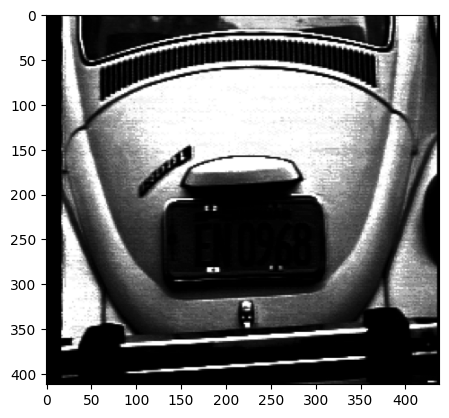

In [13]:
fusca_url = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/imgs/fusca.png"
f = mpimg.imread(download_image(fusca_url))  
plt.imshow(f,cmap='gray')
print(f.dtype)

Correção gama aplicada com sucesso com gama = 0.35


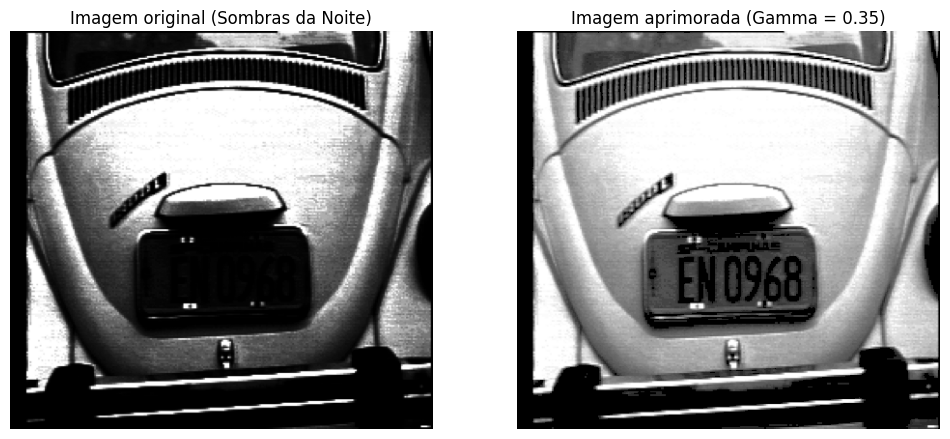

In [14]:
def apply_gamma_correction(image_array, gamma):
    # Normalizar a imagem para o intervalo [0.0, 1.0] para aplicar a função de potencia com segurança.
    # Observação: mpimg.imread pode ja carregar PNGs como float32 em [0, 1], mas isso garante a segurança.
    img_max = np.max(image_array)
    img_normalized = image_array / img_max
    
    # Aplicando a transformação gama não linear
    enhanced_array = img_normalized ** gamma
    
    print(f"Correção gama aplicada com sucesso com gama = {gamma}")
    return enhanced_array

# Definir um valor gama inferior a 1 clareia as sombras e revela a placa.
gamma_value = 0.35

# Aplicando a transformação a matriz 'f'
enhanced_fusca = apply_gamma_correction(f, gamma_value)

# Visualização lado a lado das imagens original e transformada para comparação.
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(f, cmap='gray')
plt.title("Imagem original (Sombras da Noite)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(enhanced_fusca, cmap='gray')
plt.title(f"Imagem aprimorada (Gamma = {gamma_value})")
plt.axis('off')

plt.show()

# Para revelar a placa do carro, é preciso resolver o problema de que ela está "escondida" numa região
# de muita sombra(pixels com intensidades muito proximos de zero).
# Se aplicar uma transformação linear(como apenas somar um valor para clarear), as areas que ja estão claras
# na imagem ficarão saturadas rapidamente, e o contraste na area de sombra pode continuar insuficiente para leitura.
# A solução mais adequada é aplicar uma transformação não-linear, especificamente a Correção Gama(Transformação de Potencia)
# Ao utilizarmos um valor de gamma < 1 (gama fracionario, como 0.3 ou 0.4), 
# a função "estica" os valores dos pixels escuros para que eles ocupem uma faixa muito maior de tons de cinza. 
# Isso aumenta drasticamente o contraste nas regiões de sombra, revelando a placa, 
# enquanto as areas claras sofrem menos alteração e não perdem totalmente seus detalhes.

### Exercício 2.2

Uma das possíveis aplicações das transformações radiométricas é a segmentação de imagens, onde destacamos um objeto de interesse dos demais objetos (ou do fundo). 

**a)** A imagem abaixo mostra duas bolachas. Escolha um valor de limiar (threshold) para separar a bolacha do fundo da imagem. Crie uma função de transformação T e aplique esta transformação para obter os objetos de interesse (bolachas) pintados de branco e o fundo em preto. Comente os métodos utilizados.

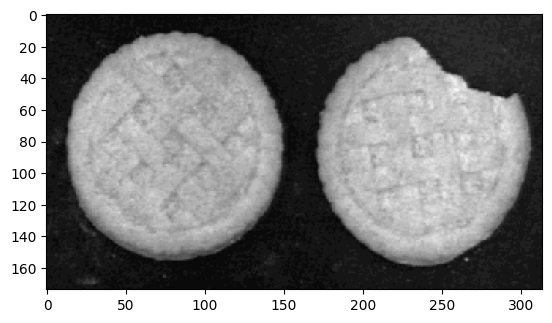

In [15]:
cookies_url = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/imgs/cookies.pgm"
plt.subplot(111)  
f = mpimg.imread(download_image(cookies_url))  
plt.imshow(f,cmap='gray')

Limiar(Threshold) aplicado com sucesso. Valor do limiar(Threshold): 120 
Invertida: False


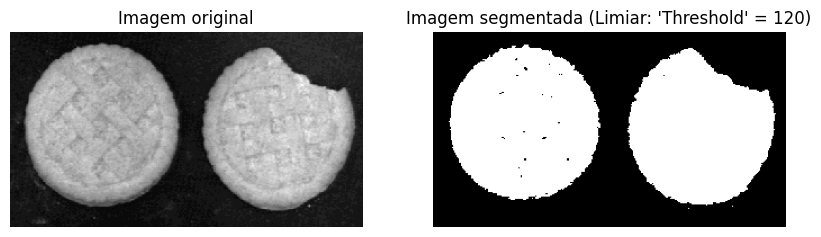

In [16]:
def apply_threshold_transformation(image_array, threshold_value, invert = False):
    # Preparando o array para garantir que seja do tipo inteiro (uint8)
    working_array: np.ndarray = image_array.copy()
    
    # Verificando se o array é composto por numeros de ponto flutuante
    if working_array.dtype != np.uint8:
        # Se o matplotlib carregou a imagem normalizada entre 0,0 e 1,0, dimensione-a para 255
        if np.max(working_array) <= 1.0:
            working_array = working_array * 255.0
        
        # Convertendo o array para inteiros para que possa ser usado como indices
        working_array = working_array.astype(np.uint8)

    # Gerando uma matriz de 0 a 255 representando todas as intensidades de pixel uint8 possiveis
    T = np.arange(256, dtype=np.uint8)
    
    # Construindo a função de transformação T com base no limiar(Threshold)
    if invert:
        T = np.where(T < threshold_value, 255, 0).astype(np.uint8)
    else:
        T = np.where(T > threshold_value, 255, 0).astype(np.uint8)
        
    # Aplicando a transformação T diretamente ao array de inteiros corrigido
    segmented_img = T[working_array]
    
    print(f"Limiar(Threshold) aplicado com sucesso. Valor do limiar(Threshold): {threshold_value} \nInvertida: {invert}")
    return segmented_img

# Testando a função corrigida
chosen_threshold = 120
segmented_cookies = apply_threshold_transformation(f, chosen_threshold, invert=False)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(f, cmap='gray')
plt.title("Imagem original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(segmented_cookies, cmap='gray')
plt.title(f"Imagem segmentada (Limiar: 'Threshold' = {chosen_threshold})")
plt.axis('off')

plt.show()

# Analisando a imagem original, as bolachas são a parte mais clara da imagem (intensidades mais altas), 
# enquanto o fundo é a parte mais escura (intensidades mais baixas).
# Quando a função foi chamada com invert=False, a logica aplicada foi: 
# "transforme tudo que for maior que 120 (o fundo claro) em branco (255), e o restante em preto (0)".
# Caso o invert seja verdadeiro(invert=True), a logica seria o contrario:
# "transforme tudo que for menor que 120 (o fundo escuro) em branco (255), e o restante em preto (0)".
# Para atingir o objetivo do enunciado (bolachas brancas e fundo preto), basta deixar o parametro invert=False. 
# Dessa forma, os pixels com intensidade maior que o limiar (as bolachas) ficarão brancos.


### Exercício 2.3 

In [17]:
orquidea_url = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/imgs/orquideafeec-calua.jpg"
download_image(orquidea_url)

'orquideafeec-calua.jpg'

Leia e apresente a imagem `orquideafeec-calua.jpg`. Execute processamentos de intensidade nas diferentes bandas da imagem (R, G, B). Comente os métodos utilizados e resultados obtidos. É possível segmentar a flor da orquídea usando uma única banda de cor?

Dica: exemplos disponíveis em [Applying point transforms e Processing individual bands](https://pillow.readthedocs.io/en/stable/handbook/tutorial.html#image-enhancement).

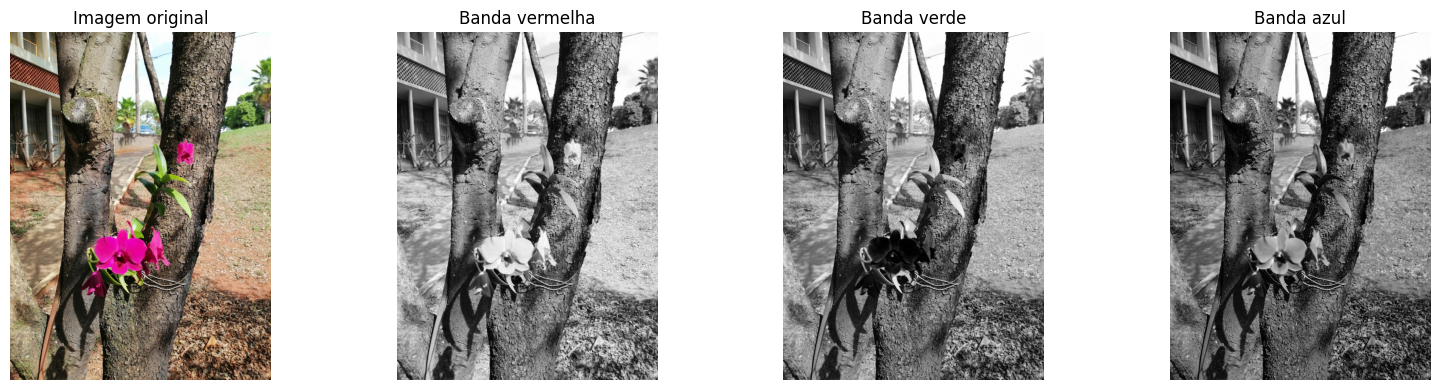

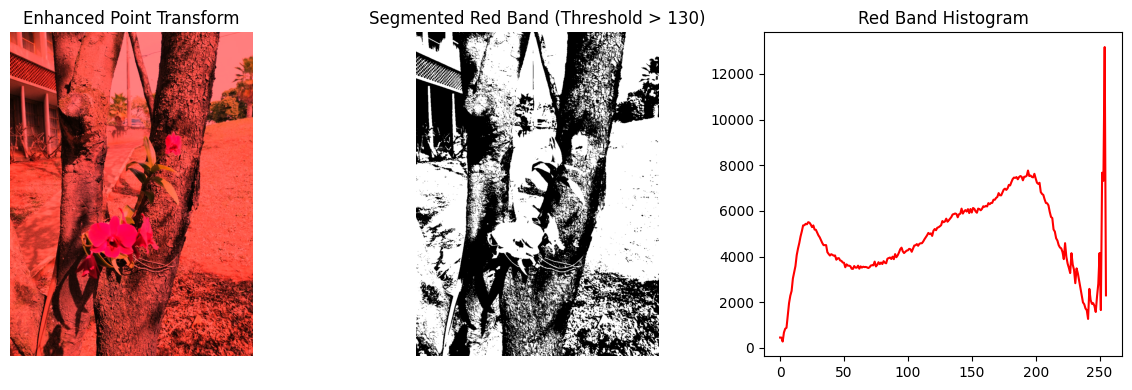

In [18]:
def process_and_evaluate_bands(filename): 
    img = Image.open(filename)
    # Separando as bandas
    # O método split() cria uma tupla de imagens individuais de banda única (R, G, B)
    r, g, b = img.split()
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(img)
    axes[0].set_title('Imagem original')
    axes[1].imshow(r, cmap='gray')
    axes[1].set_title('Banda vermelha')
    axes[2].imshow(g, cmap='gray')
    axes[2].set_title('Banda verde')
    axes[3].imshow(b, cmap='gray')
    axes[3].set_title('Banda azul')
    
    for ax in axes:
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

    # Aplicando Transformações de Ponto
    # Usamos o metodo point() para processar intensidades.
    # Aqui, aumentamos a intensidade da banda vermelha e diminuimos a verde e a azul para realçar a flor.
    r_enhanced = r.point(lambda i: i * 1.5)
    g_enhanced = g.point(lambda i: i * 0.5)
    b_enhanced = b.point(lambda i: i * 0.5)
    
    # Combinando as bandas aprimoradas de volta em uma unica imagem RGB.
    enhanced_img = Image.merge("RGB", (r_enhanced, g_enhanced, b_enhanced))
    
    # Segmentando a flor usando uma única banda
    # Ao analisar a banda vermelha, as flores (tipicamente rosa/magenta/brancas) apresentam alta intensidade,
    # enquanto as folhas verdes e o fundo apresentam baixa intensidade na banda vermelha.
    # Aplicamos uma transformação de limiar para binarizar a imagem.
    threshold = 130
    r_segmented = r.point(lambda i: 255 if i > threshold else 0)
    
    fig2, axes2 = plt.subplots(1, 3, figsize=(12, 4))
    axes2[0].imshow(enhanced_img)
    axes2[0].set_title('Enhanced Point Transform')
    axes2[1].imshow(r_segmented, cmap='gray')
    axes2[1].set_title(f'Segmented Red Band (Threshold > {threshold})')
    axes2[2].plot(r.histogram(), color='red')
    axes2[2].set_title('Red Band Histogram')
    
    for ax in axes2[:2]:
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

local_filename = "orquideafeec-calua.jpg"
process_and_evaluate_bands(local_filename)

# Análise dos Métodos e Resultados:
# Para realizar o processamento e a segmentação da imagem, os seguintes métodos da biblioteca PIL foram combinados:
# split(): Utilizado para decompor a imagem original em seus três canais fundamentais de cores (Vermelho, Verde e Azul - RGB).
# Isso permitiu analisar o comportamento da luz e o contraste da cena em cada espectro individualmente.
# point(): O principal método para as transformações radiométricas. Ele aplica uma função 
# (neste caso, operações matemáticas via lambda) pixel a pixel. Foi utilizado de duas formas:
# Aprimoramento (Enhancement): Multiplicando as intensidades para realçar o canal vermelho e atenuar o verde e o azul.
# Limiarização (Thresholding): Aplicando uma regra lógica de corte (i > 130)
# para transformar a imagem em escala de cinza em uma imagem binária (preto e branco).
# histogram(): Extraiu a distribuição de frequências das intensidades dos pixels da banda vermelha. 
# A visualização desse histograma foi crucial para validar matematicamente a escolha do limiar (threshold) de 130, 
# localizando o "vale" que separa os pixels escuros (fundo) dos pixels claros (flor).
# merge(): Recombinou as bandas individuais processadas de volta em uma única composição RGB, 
# permitindo visualizar o efeito do aprimoramento em cores.

# É possível segmentar a flor da orquídea usando uma única banda de cor?
# Sim, é perfeitamente possível. Neste caso, a banda vermelha (Red) provou ser suficiente para uma segmentação de qualidade.

# Por que isso acontece?
# A resposta está na forma como os objetos interagem com a luz. As pétalas da orquídea (de tons rosa/magenta) 
# refletem uma grande quantidade de luz vermelha, 
# fazendo com que a flor apareça com intensidades muito altas (quase brancas) no canal vermelho.
# Em contrapartida, as folhas e os troncos ao redor possuem um comportamento oposto: 
# a clorofila presente nas plantas verdes absorve fortemente a luz vermelha e azul para realizar a fotossíntese, 
# refletindo predominantemente a luz verde. Consequentemente, na visualização isolada da banda vermelha, 
# a folhagem e o fundo aparecem muito escuros.
# Esse contraste natural extremo dentro de um único canal (flor clara x fundo escuro) 
# torna a aplicação de um simples limiar (threshold) suficiente para isolar o objeto de interesse
# sem a necessidade de processamentos complexos envolvendo múltiplas bandas simultaneamente.

## Parte 3 - Contando moedas em uma imagem (opicional para EA979)

In [19]:
url_base = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/imgs/{value}.jpg"
values = [75, 80, 95]

filenames = []

for value in values:
    url = url_base.format(value=value)
    filename = download_image(url)
    filenames.append(filename)

Observe atentamente e tente entender os códigos abaixo, que aplicam diversas funções e conceitos para obter o valor total de um conjunto de moedas (de 5, 10 ou 25 centavos) presentes em uma imagem. De maneira geral, foram utilizadas funções de limiarização, obtenção de componentes conexos e morfologia matemática.

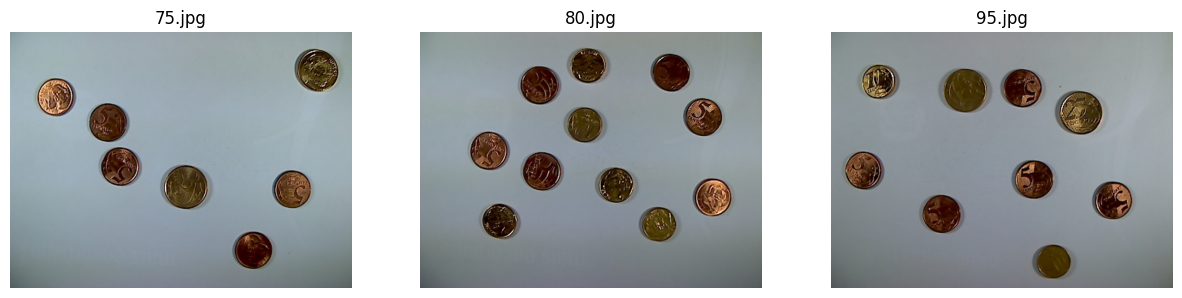

In [20]:
fig, axs = plt.subplots(1,3,figsize=(15, 6))

for i, file in enumerate(filenames):
  plt.subplot(1,3,1+i)
  plt.axis('off')
  plt.title(file)
  img = mpimg.imread(file)
  plt.imshow(img)

In [21]:
import cv2

def seg_and_postprocessing(img, k_cl, k_op):
    binr = cv2.threshold(255 - img, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)[1]

    kernel_cl = np.ones((k_cl, k_cl), np.uint8) 
    kernel_op = np.ones((k_op, k_op), np.uint8) 
    
    close = cv2.morphologyEx(binr, cv2.MORPH_CLOSE, kernel_cl, iterations=1) 
    open = cv2.morphologyEx(close, cv2.MORPH_OPEN, kernel_op, iterations=1)

    plt.figure(figsize=(12,6))
    plt.subplot(1,3,1)
    plt.imshow(binr, cmap='gray')
    plt.axis('off')
    plt.subplot(1,3,2)
    plt.imshow(close, cmap='gray')
    plt.axis('off')
    plt.subplot(1,3,3)
    plt.imshow(open, cmap='gray')
    plt.axis('off')
    plt.show()

    return open

In [22]:
def calc_npixels_label(img, n_labels):
    list_npixels = []
    for v in range(n_labels-1):
        npixels = (img[img == v+1]//(v+1)).sum()
        list_npixels.append(npixels)
    return list_npixels

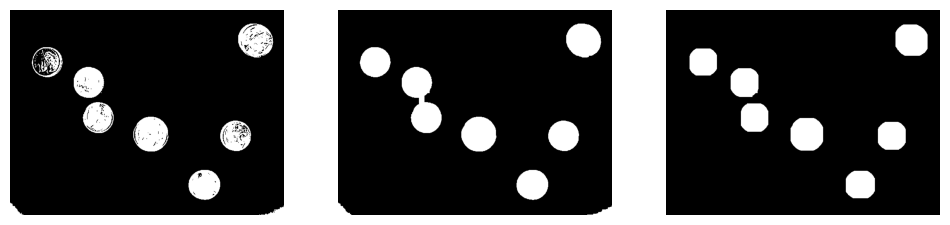

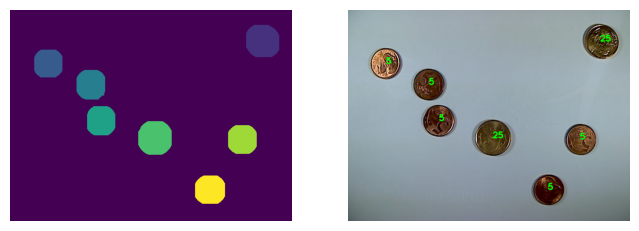

Imagem 75.jpg
Número de moedas 7
[np.int64(4805), np.int64(3638), np.int64(3867), np.int64(3786), np.int64(5016), np.int64(3767), np.int64(3861)]
Valor total: 75



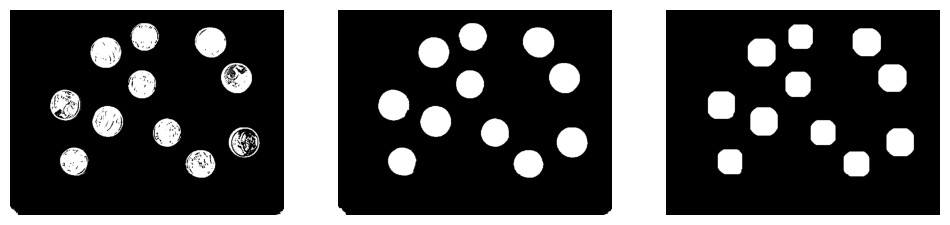

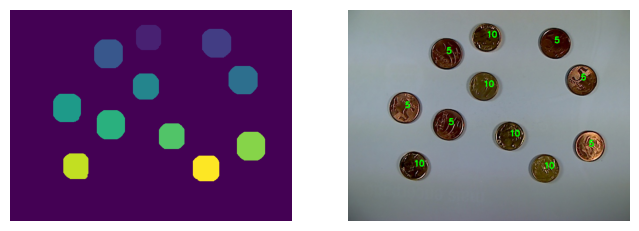

Imagem 80.jpg
Número de moedas 11
[np.int64(2978), np.int64(3793), np.int64(3775), np.int64(3736), np.int64(3132), np.int64(3678), np.int64(3778), np.int64(3064), np.int64(3728), np.int64(3049), np.int64(3183)]
Valor total: 80



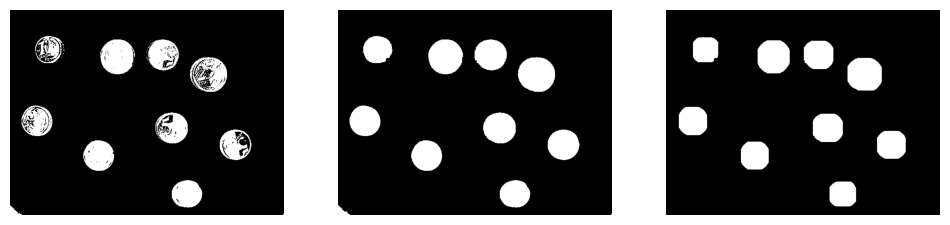

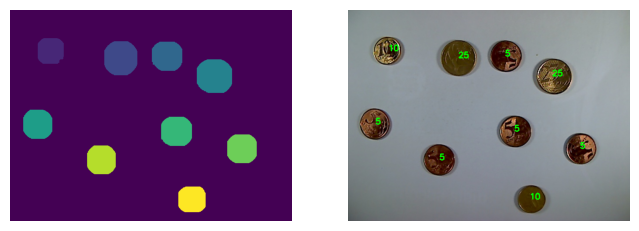

Imagem 95.jpg
Número de moedas 9
[np.int64(3114), np.int64(4997), np.int64(4017), np.int64(5335), np.int64(3845), np.int64(4113), np.int64(3897), np.int64(3766), np.int64(3285)]
Valor total: 95



In [23]:
for i, file in enumerate(filenames):
  img = mpimg.imread(file).astype('uint8')
  img_gray = np.uint8(0.3*img[:,:,0]+0.59*img[:,:,1]+0.11*img[:,:,2])

  seg_img = seg_and_postprocessing(img_gray, 15, 31)
  output = cv2.connectedComponentsWithStats(seg_img, 4)

  plt.figure(figsize=(8,4))
  plt.subplot(1,2,1)
  plt.imshow(output[1])
  plt.axis('off')

  list_npixels = calc_npixels_label(output[1], output[0])

  soma = 0
  for n, p in enumerate(list_npixels):
    x = int(output[3][n+1][0])
    y = int(output[3][n+1][1])

    if p < 3500:
      soma += 10
      cv2.putText(img, '10', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    elif p > 4600:
      soma += 25
      cv2.putText(img, '25', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    else:
      soma += 5
      cv2.putText(img, '5', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

  plt.subplot(1,2,2)
  plt.imshow(img)
  plt.axis('off')
  plt.show()

  print('Imagem', file)
  print('Número de moedas', len(list_npixels))
  print(list_npixels)
  print('Valor total:', soma)
  print()

### Exercício 3.1

Utilizando como base os códigos apresentados anteriormente, crie um novo Notebook que seja uma demonstração (demo) de como obter o valor total de um conjunto de moedas em uma imagem. O Notebook deve conter uma breve descrição do problema e deve explicar passo a passo as etapas e códigos utilizados para chegar ao resultado final. Tente descrever e exemplificar cada etapa, indicando qual o seu objetivo, explicando os processamentos aplicados, as funções utilizadas e os parâmetros escolhidos. Ao final do Notebook, apresente links para referências úteis no aprofundamento dos tópicos abordados. Você também pode linkar referências interessantes ao longo do Notebook, à medida que apresenta as etapas e os conceitos relacionados.

Não se esqueça de enviar o Notebook da demo juntamente com a entrega deste Notebook!